# Práctico VAE (Variational AutoEncoders)

El objetivo de este práctico es explorar las Variational Autoencoders tanto en su implementación como sus bases teóricas.

In [1]:
#!python -m pip install torchinfo

In [2]:
import torch
import torchinfo
import numpy as np
import torch.nn as nn
from torch.optim import Adam
import matplotlib.pyplot as plt
from torchvision.datasets import MNIST
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
from mpl_toolkits.axes_grid1 import ImageGrid
from torchvision.utils import save_image, make_grid

### Dataset

In [3]:
# create a transofrm to apply to each datapoint
transform = transforms.ToTensor() #transforms.Compose([transforms.ToTensor()])

# download the MNIST datasets
path = '~/datasets'
train_dataset = MNIST(path, transform=transform, download=True)
test_dataset  = MNIST(path, transform=transform, download=True)

# create train and test dataloaders
batch_size = 100
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Running on {DEVICE}")

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9.91M/9.91M [00:02<00:00, 4.90MB/s]


Extracting C:\Users\Enrique/datasets\MNIST\raw\train-images-idx3-ubyte.gz to C:\Users\Enrique/datasets\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28.9k/28.9k [00:00<00:00, 214kB/s]


Extracting C:\Users\Enrique/datasets\MNIST\raw\train-labels-idx1-ubyte.gz to C:\Users\Enrique/datasets\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1.65M/1.65M [00:00<00:00, 1.92MB/s]


Extracting C:\Users\Enrique/datasets\MNIST\raw\t10k-images-idx3-ubyte.gz to C:\Users\Enrique/datasets\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4.54k/4.54k [00:00<00:00, 4.55MB/s]

Extracting C:\Users\Enrique/datasets\MNIST\raw\t10k-labels-idx1-ubyte.gz to C:\Users\Enrique/datasets\MNIST\raw

Running on cuda


In [4]:
# get a batch of images
dataiter = iter(train_loader)
batch_images = next(dataiter)

In [5]:
batch_images[0].shape

torch.Size([100, 1, 28, 28])

In [6]:
# flatten batch
flatten_batch = batch_images[0].view(batch_size, 1*28*28).to(DEVICE)
flatten_batch.shape

torch.Size([100, 784])

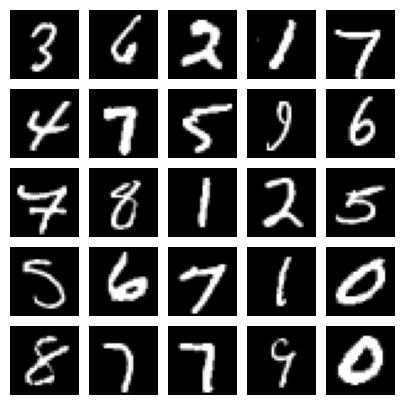

In [7]:
# get 25 sample training images for visualization
num_samples = 25
sample_images = [batch_images[0][i,0] for i in range(num_samples)]

fig = plt.figure(figsize=(5, 5))
grid = ImageGrid(fig, 111, nrows_ncols=(5, 5), axes_pad=0.1)

for ax, im in zip(grid, sample_images):
    ax.imshow(im, cmap='gray')
    ax.axis('off')

plt.show()

### Modelo VAE

In [8]:
class VAE(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=400, z_dim=200, latent_dim=2, device='cpu'):
        super(VAE, self).__init__()

        self.latent_dim = latent_dim

        self.device = device

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, z_dim),
            nn.ReLU()
        )

        self.mean_layer = nn.Linear(z_dim, latent_dim)
        self.logvar_layer = nn.Linear(z_dim, latent_dim)

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, z_dim),
            nn.ReLU(),
            nn.Linear(z_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
            nn.Sigmoid()
        )

    def encode(self, x):
        h = self.encoder(x)
        mean = self.mean_layer(h)
        logvar = self.logvar_layer(h)
        return mean, logvar

    def reparameterization(self, mean, var):
        epsilon = torch.randn_like(var).to(self.device)
        z = mean + var * epsilon
        return z

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mean, logvar = self.encode(x)
        z = self.reparameterization(mean, torch.exp(0.5 * logvar))
        x_hat = self.decode(z)
        return x_hat, mean, logvar
    
    def generate(self, num_samples=1):
        z = torch.randn(num_samples, self.latent_dim).to(self.device)
        samples = self.decode(z)
        return samples

In [9]:
LR = 0.001

model = VAE(device=DEVICE).to(DEVICE)
optimizer = Adam(model.parameters(), lr=LR)

In [10]:
torchinfo.summary(model, input_size=(100,784), col_names = ('input_size', 'output_size', 'num_params'))

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
VAE                                      [100, 784]                [100, 784]                --
├─Sequential: 1-1                        [100, 784]                [100, 200]                --
│    └─Linear: 2-1                       [100, 784]                [100, 400]                314,000
│    └─ReLU: 2-2                         [100, 400]                [100, 400]                --
│    └─Linear: 2-3                       [100, 400]                [100, 200]                80,200
│    └─ReLU: 2-4                         [100, 200]                [100, 200]                --
├─Linear: 1-2                            [100, 200]                [100, 2]                  402
├─Linear: 1-3                            [100, 200]                [100, 2]                  402
├─Sequential: 1-4                        [100, 2]                  [100, 784]                --
│    └─Linear: 2-5      

###  Función de Pérdida

In [11]:
def loss_function(x, x_hat, mean, log_var):
    reproduction_loss = nn.functional.binary_cross_entropy(x_hat, x, reduction='sum')
    KLD = - 0.5 * torch.sum(1 + log_var - mean.pow(2) - log_var.exp())
    return reproduction_loss + KLD

### Entrenamiento

In [12]:
def train(model, optimizer, epochs, device, x_dim=784):
    model.train()
    for epoch in range(epochs):
        overall_loss = 0
        for batch_idx, (x, _) in enumerate(train_loader):
            x = x.view(batch_size, x_dim).to(device)

            optimizer.zero_grad()

            x_hat, mean, log_var = model(x)
            loss = loss_function(x, x_hat, mean, log_var)

            overall_loss += loss.item()

            loss.backward()
            optimizer.step()

        print("\tEpoch", epoch + 1, "\tAverage Loss: ", overall_loss/(batch_idx*batch_size))
    return overall_loss

In [13]:
train(model.to(DEVICE), optimizer, epochs=10, device=DEVICE)

	Epoch 1 	Average Loss:  182.40491062578255
	Epoch 2 	Average Loss:  159.5919784928005
	Epoch 3 	Average Loss:  153.698466796875
	Epoch 4 	Average Loss:  150.31562007642947
	Epoch 5 	Average Loss:  148.17331670948977
	Epoch 6 	Average Loss:  147.03255963715569
	Epoch 7 	Average Loss:  145.59373818017008
	Epoch 8 	Average Loss:  144.6731129682283
	Epoch 9 	Average Loss:  143.9380131762573
	Epoch 10 	Average Loss:  143.21751750965151


8578729.298828125

### Generación

In [14]:
def generate_digit(z_dim=2):
    x_decoded = model.generate()
    digit = x_decoded.detach().cpu().reshape(28, 28)
    #plt.title(f'[{z_sample[0,0]},{z_sample[0,1]}]')
    plt.imshow(digit, cmap='gray')
    plt.axis('off')
    plt.show()

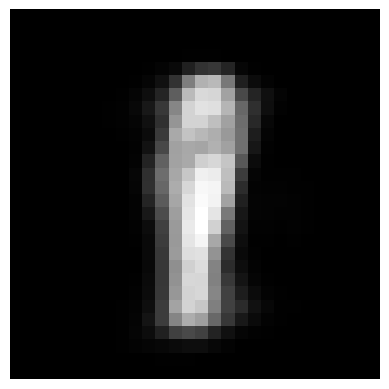

In [15]:
generate_digit()

### Mostrar el espacio latente

In [16]:
def plot_latent_space(model, scale=5.0, n=25, digit_size=28, figsize=15):
    # display a n*n 2D manifold of digits
    figure = np.zeros((digit_size * n, digit_size * n))

    # construct a grid
    grid_x = np.linspace(-scale, scale, n)
    grid_y = np.linspace(-scale, scale, n)[::-1]

    for i, yi in enumerate(grid_y):
        for j, xi in enumerate(grid_x):
            z_sample = torch.tensor([[xi, yi]], dtype=torch.float).to(DEVICE)
            x_decoded = model.decode(z_sample)
            digit = x_decoded[0].detach().cpu().reshape(digit_size, digit_size)
            figure[i * digit_size : (i + 1) * digit_size, j * digit_size : (j + 1) * digit_size,] = digit

    plt.figure(figsize=(figsize, figsize))
    plt.title('VAE Latent Space Visualization')
    start_range = digit_size // 2
    end_range = n * digit_size + start_range
    pixel_range = np.arange(start_range, end_range, digit_size)
    sample_range_x = np.round(grid_x, 1)
    sample_range_y = np.round(grid_y, 1)
    plt.xticks(pixel_range, sample_range_x)
    plt.yticks(pixel_range, sample_range_y)
    plt.xlabel("z[0]")
    plt.ylabel("z[1]")
    plt.imshow(figure, cmap="Greys_r")
    plt.show()

C:\Users\Enrique\AppData\Local\Temp\ipykernel_51220\2141494282.py:14: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  figure[i * digit_size : (i + 1) * digit_size, j * digit_size : (j + 1) * digit_size,] = digit


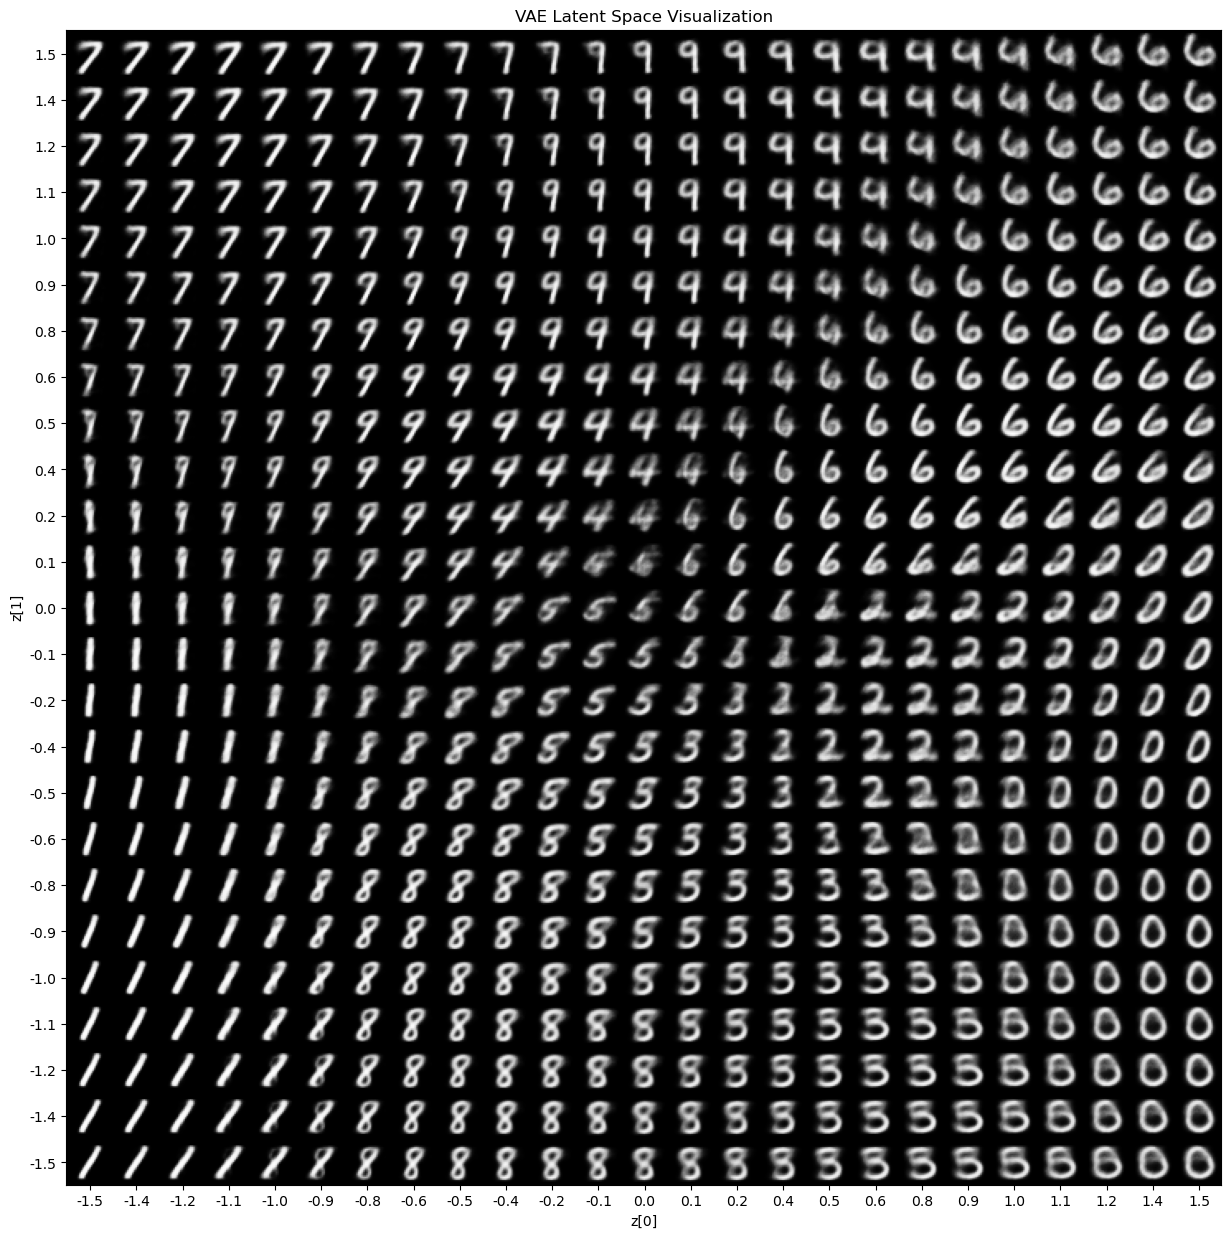

In [17]:
plot_latent_space(model, scale=1.5)

### Experimento 1: VAE con latent_dim=5

In [18]:
LATENT_DIM_EXP1 = 5
LR_EXP1 = 0.001
EPOCHS_EXP1 = 10

model_exp1 = VAE(latent_dim=LATENT_DIM_EXP1, device=DEVICE).to(DEVICE)
optimizer_exp1 = Adam(model_exp1.parameters(), lr=LR_EXP1)

print(f"Entrenando VAE con latent_dim={LATENT_DIM_EXP1}")
train(model_exp1, optimizer_exp1, epochs=EPOCHS_EXP1, device=DEVICE)

Entrenando VAE con latent_dim=5
	Epoch 1 	Average Loss:  169.81219638525147
	Epoch 2 	Average Loss:  134.0240099710455
	Epoch 3 	Average Loss:  128.60450288240818
	Epoch 4 	Average Loss:  125.64799884573247
	Epoch 5 	Average Loss:  123.55780105514398
	Epoch 6 	Average Loss:  122.08505838180822
	Epoch 7 	Average Loss:  120.81904309917572
	Epoch 8 	Average Loss:  119.81276076990297
	Epoch 9 	Average Loss:  118.95403890924979
	Epoch 10 	Average Loss:  118.24078157606428


7082622.81640625

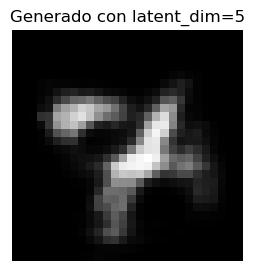

In [19]:
x_decoded = model_exp1.generate()
digit = x_decoded.detach().cpu().reshape(28, 28)
plt.figure(figsize=(3, 3))
plt.imshow(digit, cmap='gray')
plt.title(f'Generado con latent_dim={LATENT_DIM_EXP1}')
plt.axis('off')
plt.show()

Nota: plot_latent_space solo funciona con latent_dim=2, por eso no podemos visualizar el espacio latente para latent_dim=5

### Experimento 2: VAE con latent_dim=10

In [21]:
LATENT_DIM_EXP2 = 10
LR_EXP2 = 0.001
EPOCHS_EXP2 = 10

model_exp2 = VAE(latent_dim=LATENT_DIM_EXP2, device=DEVICE).to(DEVICE)
optimizer_exp2 = Adam(model_exp2.parameters(), lr=LR_EXP2)

print(f"Entrenando VAE con latent_dim={LATENT_DIM_EXP2}")
train(model_exp2, optimizer_exp2, epochs=EPOCHS_EXP2, device=DEVICE)

Entrenando VAE con latent_dim=10
	Epoch 1 	Average Loss:  168.6086532893364
	Epoch 2 	Average Loss:  124.01090707820326
	Epoch 3 	Average Loss:  116.65811841350167
	Epoch 4 	Average Loss:  113.37227270059473
	Epoch 5 	Average Loss:  111.16248684330655
	Epoch 6 	Average Loss:  109.11736192808327
	Epoch 7 	Average Loss:  107.64038082676858
	Epoch 8 	Average Loss:  106.66462685204507
	Epoch 9 	Average Loss:  105.80915751512939
	Epoch 10 	Average Loss:  105.12405985887938


6296931.185546875

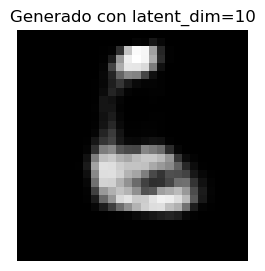

In [22]:
x_decoded = model_exp2.generate()
digit = x_decoded.detach().cpu().reshape(28, 28)
plt.figure(figsize=(3, 3))
plt.imshow(digit, cmap='gray')
plt.title(f'Generado con latent_dim={LATENT_DIM_EXP2}')
plt.axis('off')
plt.show()

### Experimento 3: VAE con hidden_dim=200

In [23]:
HIDDEN_DIM_EXP3 = 200
LATENT_DIM_EXP3 = 2
LR_EXP3 = 0.001
EPOCHS_EXP3 = 10

model_exp3 = VAE(hidden_dim=HIDDEN_DIM_EXP3, latent_dim=LATENT_DIM_EXP3, device=DEVICE).to(DEVICE)
optimizer_exp3 = Adam(model_exp3.parameters(), lr=LR_EXP3)

print(f"Entrenando VAE con hidden_dim={HIDDEN_DIM_EXP3}")
train(model_exp3, optimizer_exp3, epochs=EPOCHS_EXP3, device=DEVICE)

Entrenando VAE con hidden_dim=200
	Epoch 1 	Average Loss:  188.32803052287667
	Epoch 2 	Average Loss:  164.1954106453464
	Epoch 3 	Average Loss:  157.88363286140964
	Epoch 4 	Average Loss:  154.31037489239878
	Epoch 5 	Average Loss:  151.72054217967445
	Epoch 6 	Average Loss:  149.58295275654737
	Epoch 7 	Average Loss:  148.06468756521286
	Epoch 8 	Average Loss:  146.84999184839316
	Epoch 9 	Average Loss:  145.91968327746764
	Epoch 10 	Average Loss:  145.09530229418823


8691208.607421875

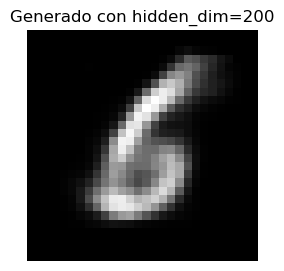

In [24]:
x_decoded = model_exp3.generate()
digit = x_decoded.detach().cpu().reshape(28, 28)
plt.figure(figsize=(3, 3))
plt.imshow(digit, cmap='gray')
plt.title(f'Generado con hidden_dim={HIDDEN_DIM_EXP3}')
plt.axis('off')
plt.show()

### Comparación de resultados de todos los modelos

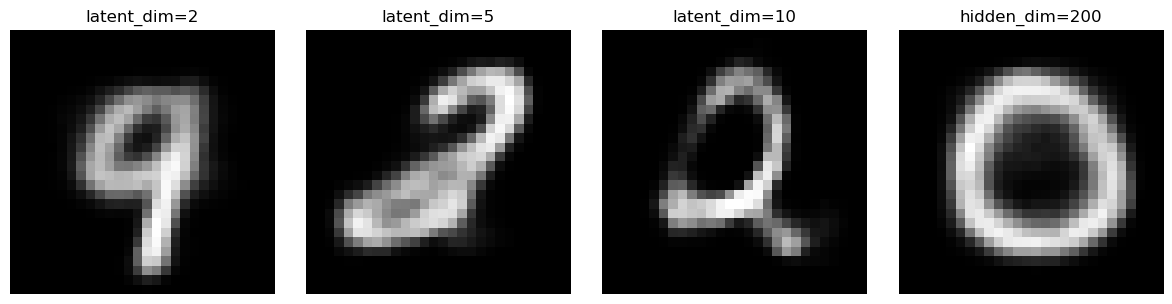

In [25]:
fig, axes = plt.subplots(1, 4, figsize=(12, 3))

models = [model, model_exp1, model_exp2, model_exp3]
titles = ['latent_dim=2', f'latent_dim={LATENT_DIM_EXP1}', f'latent_dim={LATENT_DIM_EXP2}', f'hidden_dim={HIDDEN_DIM_EXP3}']

for i, (m, title) in enumerate(zip(models, titles)):
    x_decoded = m.generate()
    digit = x_decoded.detach().cpu().reshape(28, 28)
    axes[i].imshow(digit, cmap='gray')
    axes[i].set_title(title)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

## Ejercicios

1. Complete el código.
2. ¿Por qué es necesario el truco de reparametrización en las VAE?
3. ¿Qué representan las variables mean y var en la VAE?
4. Cree y entrene nuevas VAE modificando los hiperparámetros.
5. ¿Cómo afecta la elección del tamaño del espacio latente al rendimiento de la VAE?
6. ¿Qué rol juega el término de regularización KL-divergence en la función de pérdida de la VAE?
7. Explique que ve en la imágen que se genera cuando llamamos a la función `plot_latent_space`. Si cambiamos la dimensión del espacio latente, ¿qué pasaría con esta gráfica?

**Respuestas:**

2. El truco de reparametrización es necesario porque si muestreamos directamente desde la distribución latente, el muestreo no es una operación derivable y no podríamos hacer backpropagation. Entonces lo que hacemos es sacar el ruido aleatorio afuera como epsilon y la parte con parámetros (mean y var) queda derivable. Así podemos entrenar la red con gradient descent.

3. mean y var representan los parámetros de la distribución latente para cada dato. El encoder no da un único punto en el espacio latente, sino que da una distribución gaussiana. mean es la media de esa gaussiana y var es la varianza. Esto le permite a la VAE capturar la incertidumbre en la codificación.

5. El tamaño del espacio latente afecta la capacidad del modelo. Con latent_dim=2 el modelo tiene que comprimir toda la información en solo 2 dimensiones, lo que limita lo que puede representar pero hace el espacio más organizado. Con latent_dim más grande (5 o 10) el modelo tiene más espacio para representar variaciones sutiles de los dígitos, pero puede ser más difícil de entrenar y necesita más datos. En los experimentos vemos que todos los modelos generan dígitos reconocibles, lo que indica que incluso 2 dimensiones son suficientes para MNIST.

6. La KL-divergence es como una regularización que empuja a la distribución latente a parecerse a una gaussiana estándar (media 0, varianza 1). Si no tuviéramos este término, el encoder podría mandar cada dato a cualquier parte del espacio latente sin estructura. Con la KL, forzamos que el espacio latente sea continuo y organizado, lo que hace que podamos generar nuevos datos muestreando desde cualquier punto.

7. En la imagen de plot_latent_space vemos una grilla de 25x25 dígitos donde cada posición corresponde a un punto en el espacio latente 2D. Lo interesante es que los dígitos cambian de forma suave a medida que nos movemos por el espacio. Por ejemplo, en la esquina superior izquierda hay 7s y 1s, en el centro hay 9s y 4s, y en la esquina inferior derecha hay 0s. Las transiciones son continuas, no hay saltos bruscos. Esto muestra que la VAE aprendió un espacio latente organizado donde puntos cercanos generan dígitos similares. Si cambiamos la dimensión del espacio latente a más de 2, no podríamos hacer esta visualización porque estaríamos trabajando en 3 o más dimensiones y esta función solo grafica en 2D.